In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


Install required libaries.

Import required libaries.

In [2]:
!git clone https://github.com/riri324/CTGAN.git

Cloning into 'CTGAN'...
remote: Enumerating objects: 2361, done.
remote: Counting objects: 100% (1020/1020), done.
remote: Compressing objects: 100% (257/257), done.
remote: Total 2361 (delta 935), reused 763 (delta 763), pack-reused 1341 (from 3)
Receiving objects: 100% (2361/2361), 1.96 MiB | 7.97 MiB/s, done.
Resolving deltas: 100% (1479/1479), done.


In [3]:
%cd CTGAN 
!pip install -e .
!pip install -U pip
!pip install ctgan==0.7.4 rdt==1.6.0
!pip install seaborn

/kaggle/working/CTGAN
Obtaining file:///kaggle/working/CTGAN
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.3 MB/s eta 0:00:00
  Building editable for ctgan (pyproject.toml) ... done
  Created wheel for ctgan: filename=ctgan-0.11.2.dev0-0.editable-py3-none-any.whl size=8802 sha256=e5825f7ac54249e2011e984619da76b1aefe08a2dc28e8298054cda0c32d7839
  Stored in directory: /tmp/pip-ephem-wheel-cache-yg3oosvj/wheels/f4/f5/f7/30775afb577769592eca9a45507a320d88fb7d641ea0e67eb0
Successfully built ctgan
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstal

In [4]:
from ctgan import CTGAN
print("CTGAN loaded successfully")

CTGAN loaded successfully


In [5]:
import os
import pandas as pd

if os.path.exists("/kaggle/input/creditcardfraud/creditcard.csv"):
    data_path = "/kaggle/input/creditcardfraud/creditcard.csv"
else:
    data_path = "./data/creditcard.csv"

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# from sklearn.model_selection import train_test_split

# # 전체 데이터에서 5%만 사용 (테스트용)
# df_small, _ = train_test_split(
#     df,
#     test_size=0.95,             
#     stratify=df["Class"],        
#     random_state=42
# )

# print("Small DF shape:", df_small.shape)
# print("Fraud ratio:", df_small["Class"].mean())


In [7]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score

from xgboost import XGBClassifier
from ctgan import CTGAN

# Hold-out split: Baseline / GAN / Diffusion for same standards for test
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["Class"], random_state=42
)
train_base, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df["Class"], random_state=42
)
FEATURE_COLS = [c for c in df.columns if c != "Class"]

# train_df, test_df = train_test_split(
#     df_small, test_size=0.2, stratify=df_small["Class"], random_state=42
# )

# train_base, val_df = train_test_split(
#     train_df, test_size=0.2, stratify=train_df["Class"], random_state=42
# )

# FEATURE_COLS = [c for c in df_small.columns if c != "Class"]

print("Train fraud rate:", train_df["Class"].mean())
print("Test  fraud rate:", test_df["Class"].mean())

ratios = [0.3, 0.5, 0.7, 1.0]
ratios_ext = [None] + ratios          # natural (None)
discrete_columns = ["Class"]

def ratio_name(r):
    return "natural" if r is None else f"forced_{r:.2f}"

scale_pos_weight = (train_df["Class"].value_counts()[0] / train_df["Class"].value_counts()[1])
print("scale_pos_weight:", scale_pos_weight)

Train fraud rate: 0.001729245759178389
Test  fraud rate: 0.0017204452090867595
scale_pos_weight: 577.2868020304569


In [8]:
def class_ratio_cols(df, prefix):
    vc = df["Class"].value_counts()
    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    n = n0 + n1
    return {
        f"{prefix}_n": n,
        f"{prefix}_p0": n0 / n if n else np.nan,
        f"{prefix}_p1": n1 / n if n else np.nan,
        f"{prefix}_ratio": f"{(n0/n):.4f}:{(n1/n):.4f}" if n else "NA",
    }
test_ratio_cols = class_ratio_cols(test_df, "test")

In [9]:
def find_best_threshold(prob, y_true):
    thresholds = np.linspace(0.001, 0.5, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        pred = (prob > t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1, best_t = float(f1), float(t)
    return best_t, best_f1


In [10]:
from sklearn.metrics import pairwise_distances

def privacy_nn_memorization(real_df, syn_df, feature_cols, threshold=1e-6,
                            sample_real=5000, sample_syn=5000, seed=42):
    real_s = real_df.sample(n=min(sample_real, len(real_df)), random_state=seed)
    syn_s  = syn_df.sample(n=min(sample_syn, len(syn_df)), random_state=seed)

    real_X = real_s[feature_cols].values
    syn_X  = syn_s[feature_cols].values

    dists = pairwise_distances(syn_X, real_X, metric="euclidean")
    min_dists = dists.min(axis=1)

    out = {
        "NN_mean": float(min_dists.mean()),
        "NN_min": float(min_dists.min()),
        "NearDup_rate(thr)": float((min_dists < threshold).mean())
    }

    real_fraud = real_df[real_df.Class==1]
    syn_fraud  = syn_df[syn_df.Class==1]
    if len(real_fraud) > 0 and len(syn_fraud) > 0:
        rf = real_fraud.sample(n=min(2000, len(real_fraud)), random_state=seed)[feature_cols].values
        sf = syn_fraud.sample(n=min(2000, len(syn_fraud)), random_state=seed)[feature_cols].values
        d_f = pairwise_distances(sf, rf, metric="euclidean")
        min_d_f = d_f.min(axis=1)
        out["Fraud_NN_mean"] = float(min_d_f.mean())
        out["Fraud_NN_min"]  = float(min_d_f.min())
    else:
        out["Fraud_NN_mean"] = np.nan
        out["Fraud_NN_min"]  = np.nan

    return out

def real_real_nn_baseline(real_df, feature_cols, class_value=None, n_sample=2000, seed=42):
    if class_value is None:
        X = real_df[feature_cols].values
    else:
        X = real_df[real_df["Class"] == class_value][feature_cols].values

    rng = np.random.default_rng(seed)
    n = min(n_sample, len(X))
    if n < 2:
        return {"RealReal_NN_mean": np.nan, "RealReal_NN_min": np.nan, "n_used": n}

    idx1 = rng.choice(len(X), n, replace=False)
    idx2 = rng.choice(len(X), n, replace=False)
    X1, X2 = X[idx1], X[idx2]

    d = pairwise_distances(X1, X2, metric="euclidean")
    np.fill_diagonal(d, np.inf)
    min_d = d.min(axis=1)
    return {"RealReal_NN_mean": float(min_d.mean()), "RealReal_NN_min": float(min_d.min()), "n_used": n}


In [11]:
privacy_rows_ctgan = []
imbalance_rows_ctgan = []

# Real-Real baseline
baseline_all  = real_real_nn_baseline(train_base, FEATURE_COLS, class_value=None, n_sample=2000)
baseline_fraud = real_real_nn_baseline(train_base, FEATURE_COLS, class_value=1, n_sample=2000)

baseline_df = pd.DataFrame([
    {"syn_ratio": "BASELINE_REALREAL_ALL",
     "NN_mean": baseline_all["RealReal_NN_mean"],
     "NN_min":  baseline_all["RealReal_NN_min"]},
    {"syn_ratio": "BASELINE_REALREAL_FRAUD",
     "Fraud_NN_mean": baseline_fraud["RealReal_NN_mean"],
     "Fraud_NN_min":  baseline_fraud["RealReal_NN_min"]},
]).set_index("syn_ratio")

In [12]:
def evaluate_holdout_xgb(train_any_df, val_df, test_df, xgb_params):
    X_train = train_any_df.drop(columns=["Class"])
    y_train = train_any_df["Class"]

    X_val = val_df.drop(columns=["Class"])
    y_val = val_df["Class"]

    X_test = test_df.drop(columns=["Class"])
    y_test = test_df["Class"]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    model = XGBClassifier(**xgb_params)
    model.fit(X_train_s, y_train)

    val_prob = model.predict_proba(X_val_s)[:, 1]
    best_t, best_f1 = find_best_threshold(val_prob, y_val)

    test_prob = model.predict_proba(X_test_s)[:, 1]
    pred_fixed = (test_prob > 0.5).astype(int)
    pred_opt   = (test_prob > best_t).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "AUPRC": average_precision_score(y_test, test_prob),
        "F1@0.5": f1_score(y_test, pred_fixed),
        "Recall@0.5": recall_score(y_test, pred_fixed),
        "F1@opt": f1_score(y_test, pred_opt),
        "Recall@opt": recall_score(y_test, pred_opt),
        "Best_threshold": best_t,
        "Best_F1_on_VAL": best_f1,
        "test_prob": test_prob
    }

In [13]:
def get_cm_and_class_f1(y_true, y_pred):
    """
    반환:
      cm (2x2): [[TP, FN],
                [FP, TN]] 형태가 아니라,
                labels=[1,0] 기준으로
                [[True=1 Pred=1, True=1 Pred=0],
                 [True=0 Pred=1, True=0 Pred=0]]
                즉:
                [[TP, FN],
                 [FP, TN]]
    """
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # Fraud(1) first, Normal(0) second

    f1_fraud = f1_score(y_true, y_pred, pos_label=1)  # Fraud F1
    f1_norm  = f1_score(y_true, y_pred, pos_label=0)  # Normal F1
    return cm, f1_fraud, f1_norm


def plot_cm(cm, title):
    plt.figure(figsize=(5,4), dpi=150)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fraudulent", "Legitimate"],
        yticklabels=["Fraudulent", "Legitimate"],
        cbar_kws={"label": "Count"},
        linewidths=1,
        linecolor="white"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [14]:
# Hold-out Baseline / GAN / Diffusion same parameters for fairness
XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
XGB_PARAMS_ON  = {**XGB_PARAMS, "scale_pos_weight": scale_pos_weight}
XGB_PARAMS_OFF = {**XGB_PARAMS}

# baseline_holdout = evaluate_holdout_xgb(train_df, test_df, XGB_PARAMS)
# baseline_holdout

Init and set experiment parameters.


[CTGAN] Training ratio = natural


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  -> Running privacy check for natural

[natural | syn_only_spw_ON]  (thr=0.500)
Fraud F1 = 0.0248
Legit F1 = 0.9336


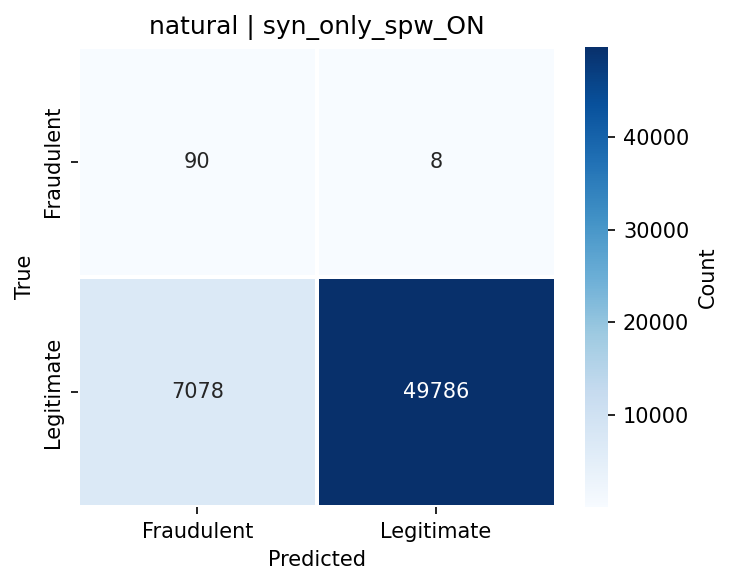


[natural | syn_only_spw_OFF]  (thr=0.500)
Fraud F1 = 0.1640
Legit F1 = 0.9921


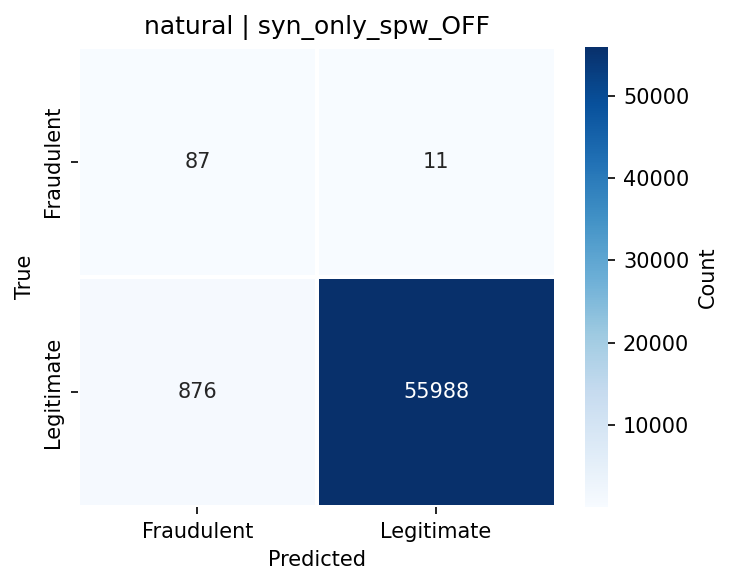


[natural | hybrid_spw_ON]  (thr=0.500)
Fraud F1 = 0.1095
Legit F1 = 0.9871


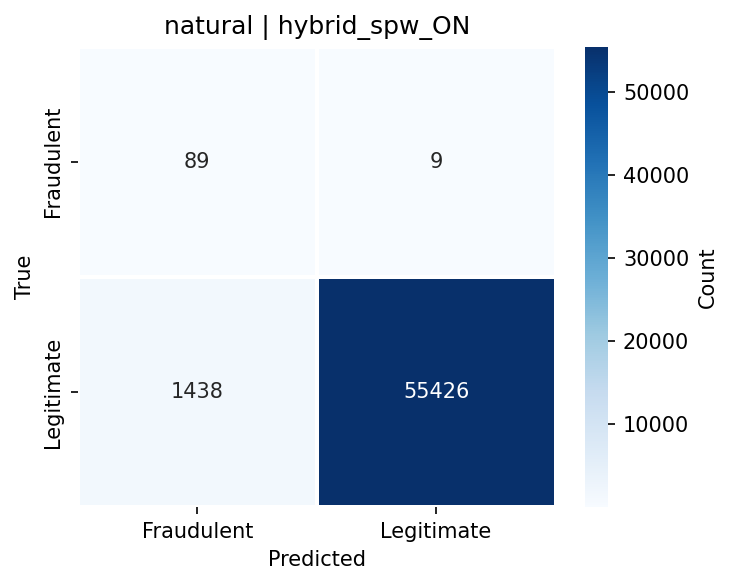


[natural | hybrid_spw_OFF]  (thr=0.500)
Fraud F1 = 0.7456
Legit F1 = 0.9995


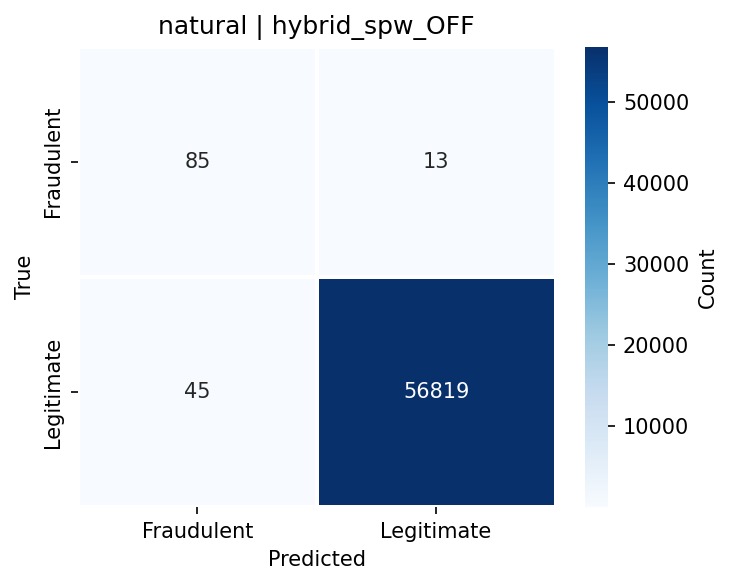


[CTGAN] Training ratio = forced_0.30

[forced_0.30 | syn_only_spw_ON]  (thr=0.500)
Fraud F1 = 0.0090
Legit F1 = 0.7781


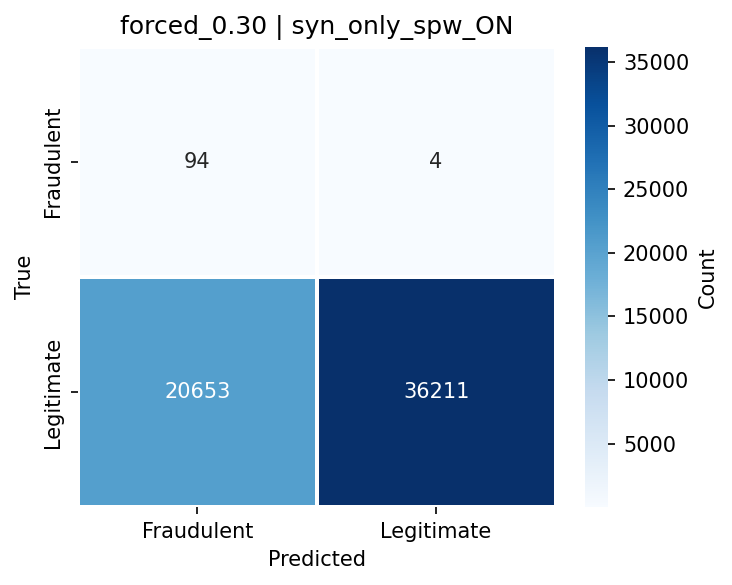


[forced_0.30 | syn_only_spw_OFF]  (thr=0.497)
Fraud F1 = 0.7453
Legit F1 = 0.9995


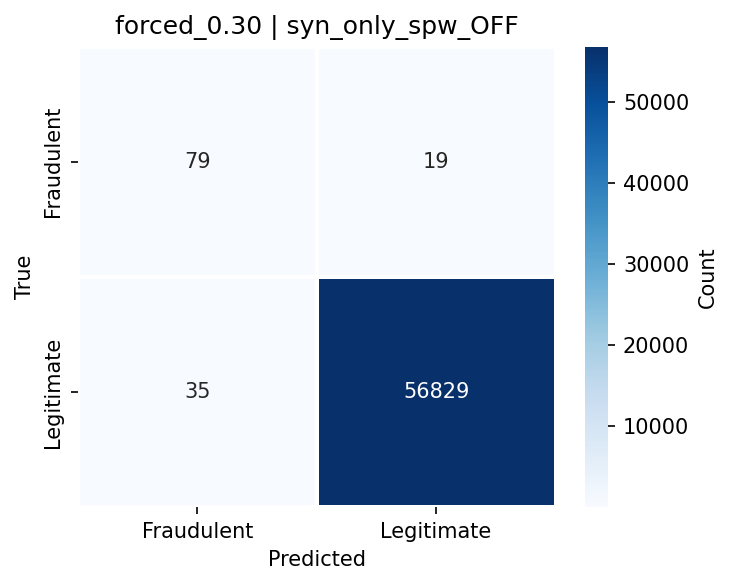


[forced_0.30 | hybrid_spw_ON]  (thr=0.500)
Fraud F1 = 0.0557
Legit F1 = 0.9724


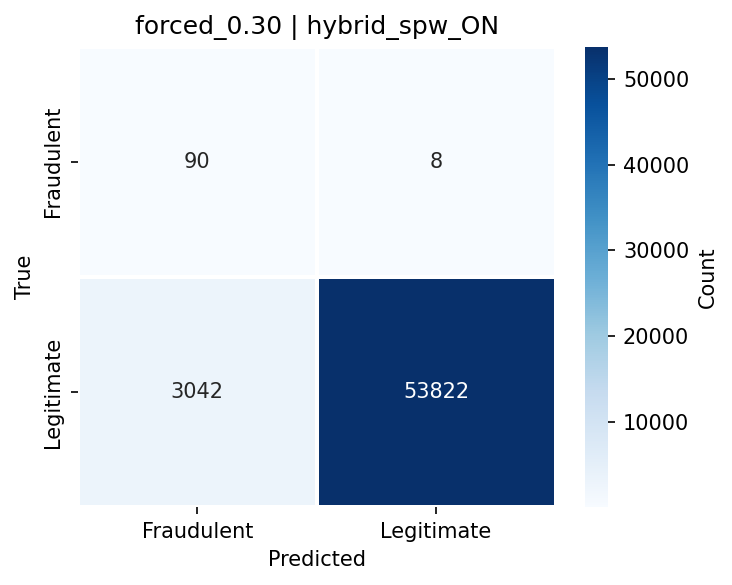


[forced_0.30 | hybrid_spw_OFF]  (thr=0.337)
Fraud F1 = 0.8325
Legit F1 = 0.9997


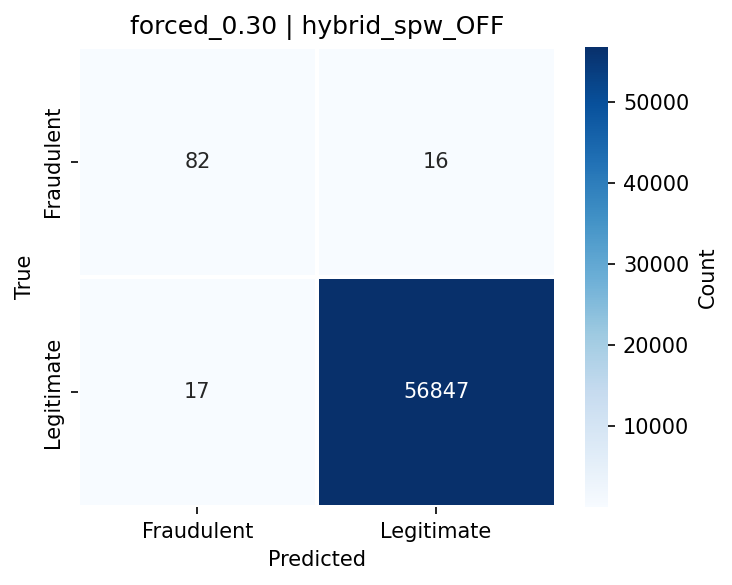


[CTGAN] Training ratio = forced_0.50
  -> Running privacy check for forced_0.50

[forced_0.50 | syn_only_spw_ON]  (thr=0.500)
Fraud F1 = 0.0035
Legit F1 = 0.0461


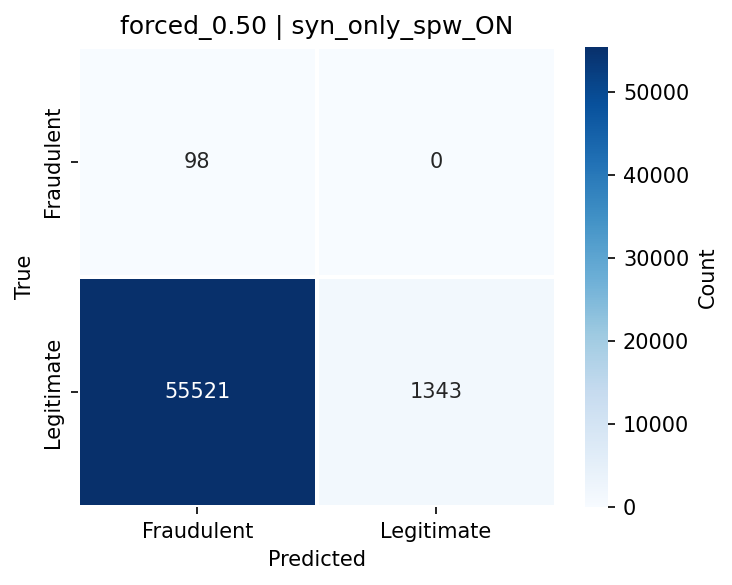


[forced_0.50 | syn_only_spw_OFF]  (thr=0.500)
Fraud F1 = 0.1034
Legit F1 = 0.9867


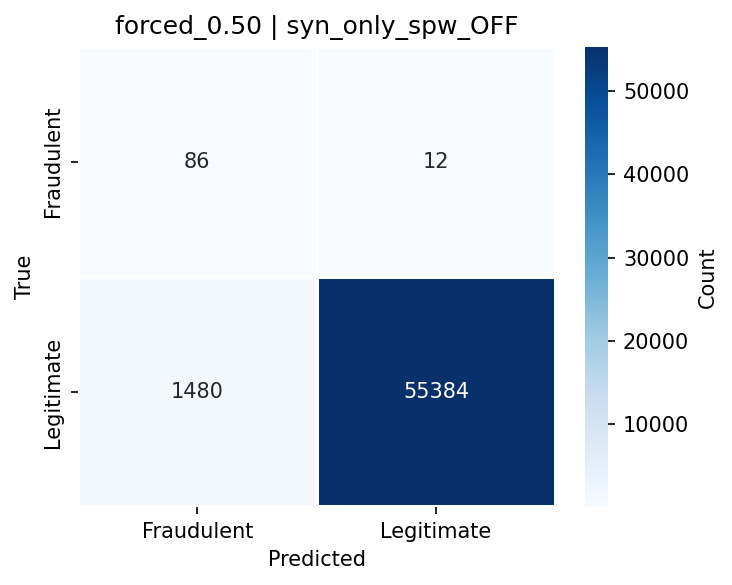


[forced_0.50 | hybrid_spw_ON]  (thr=0.497)
Fraud F1 = 0.0129
Legit F1 = 0.8499


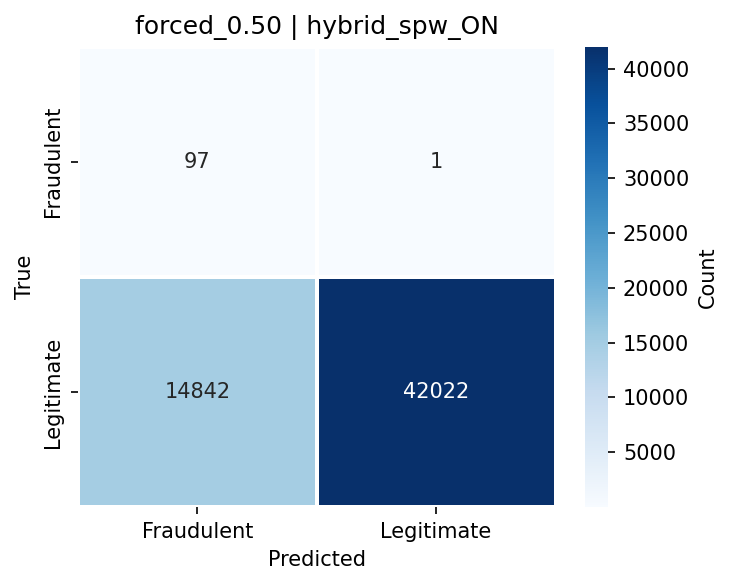


[forced_0.50 | hybrid_spw_OFF]  (thr=0.492)
Fraud F1 = 0.7826
Legit F1 = 0.9996


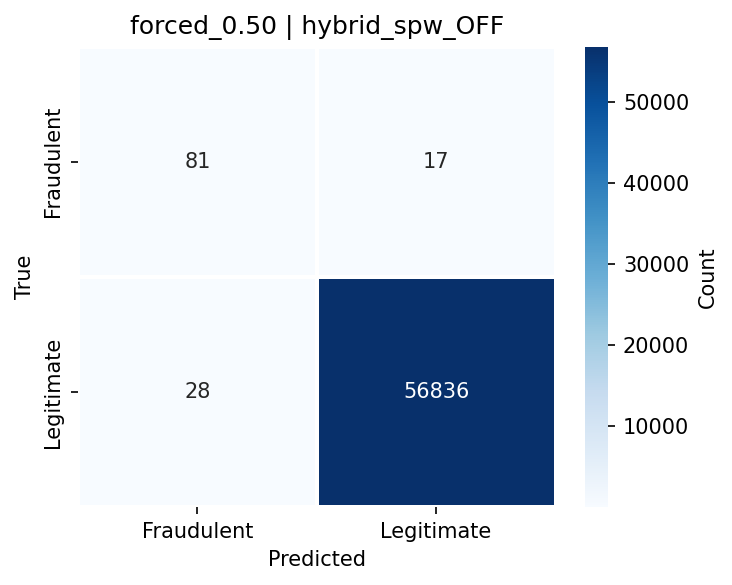


[CTGAN] Training ratio = forced_0.70

[forced_0.70 | syn_only_spw_ON]  (thr=0.001)
Fraud F1 = 0.0034
Legit F1 = 0.0000


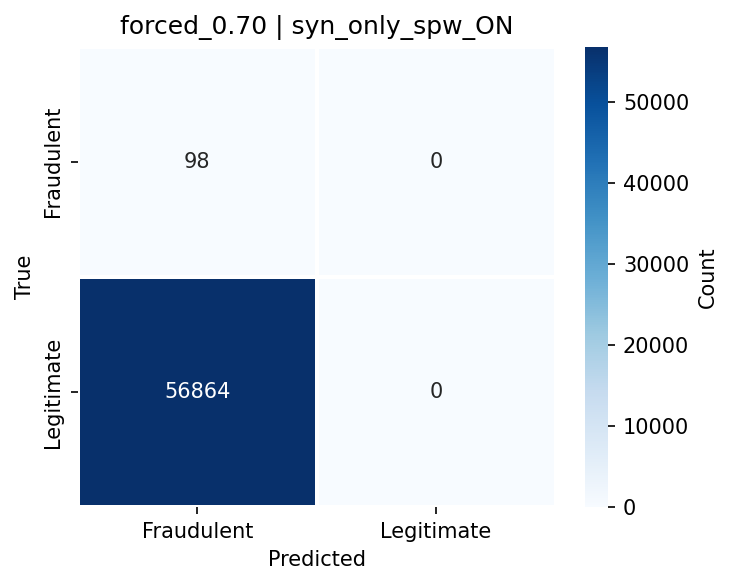


[forced_0.70 | syn_only_spw_OFF]  (thr=0.500)
Fraud F1 = 0.0037
Legit F1 = 0.1299


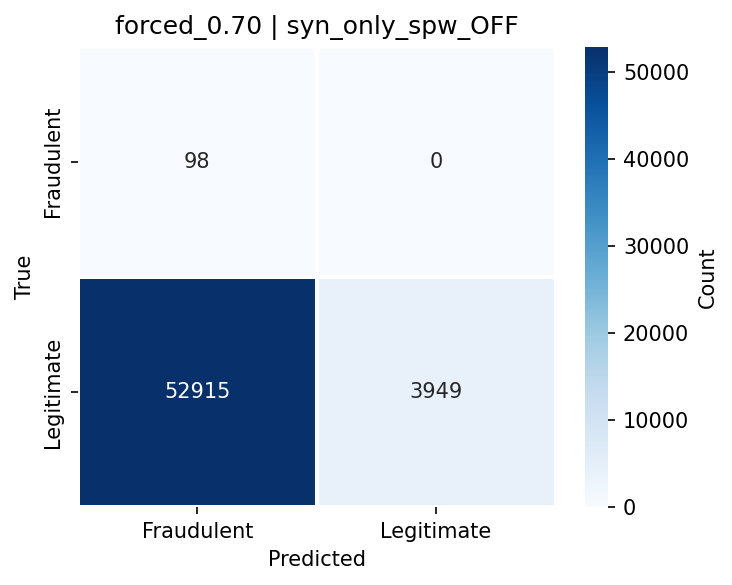


[forced_0.70 | hybrid_spw_ON]  (thr=0.495)
Fraud F1 = 0.0132
Legit F1 = 0.8594


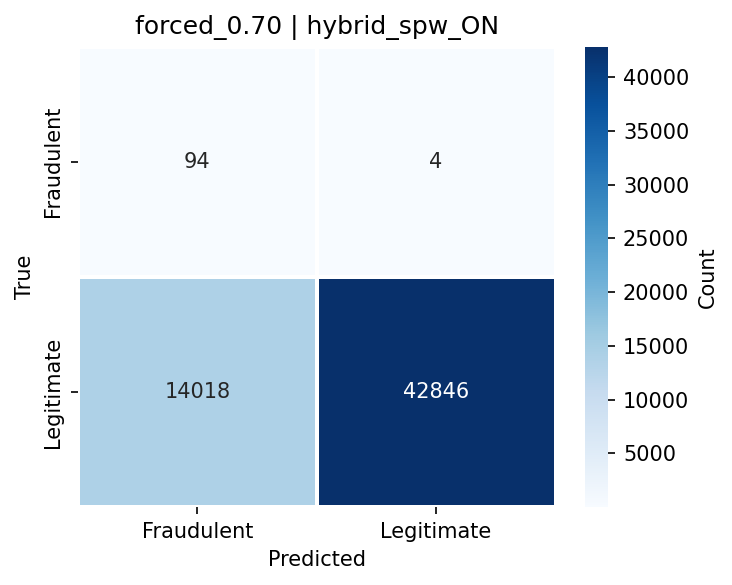


[forced_0.70 | hybrid_spw_OFF]  (thr=0.500)
Fraud F1 = 0.6189
Legit F1 = 0.9991


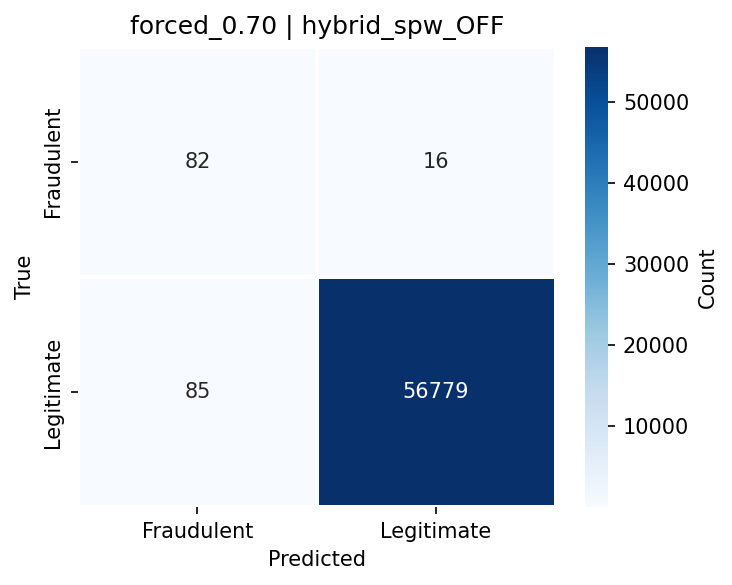


[CTGAN] Training ratio = forced_1.00
  -> skip syn-only (only one class in syn): [1]

[forced_1.00 | hybrid_spw_ON]  (thr=0.500)
Fraud F1 = 0.0504
Legit F1 = 0.9682


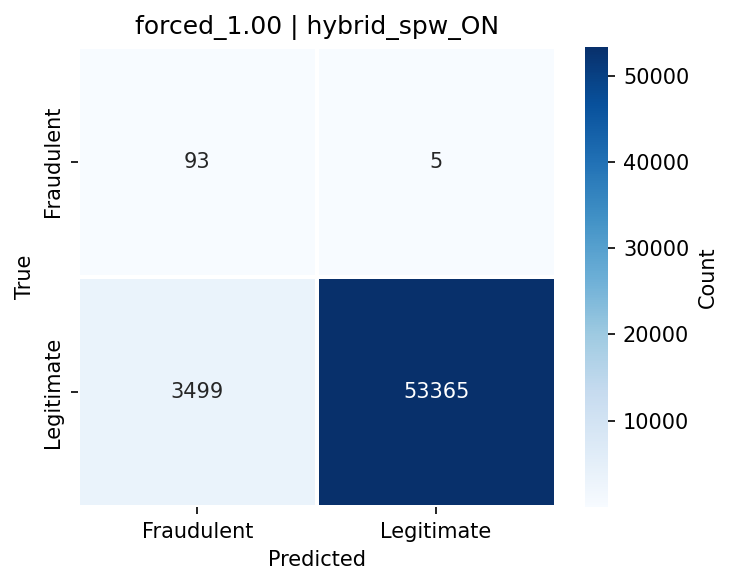


[forced_1.00 | hybrid_spw_OFF]  (thr=0.495)
Fraud F1 = 0.6437
Legit F1 = 0.9992


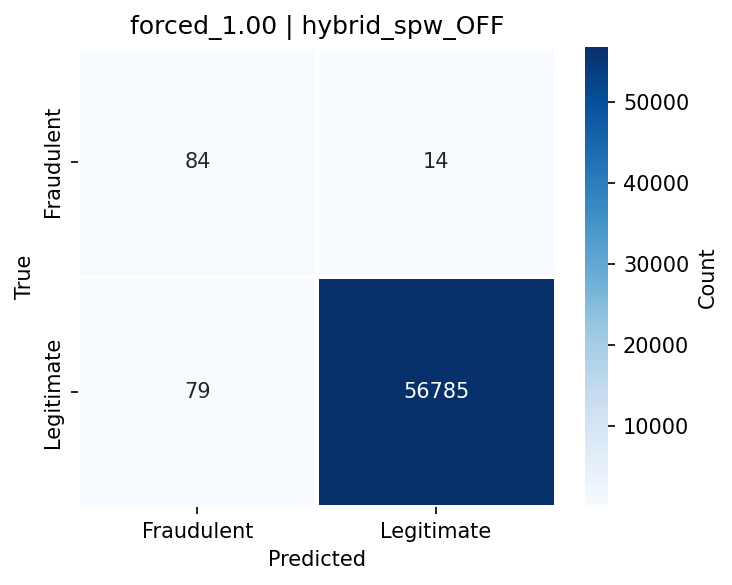

ROC-AUC     AUPRC  F1_fraud  F1_legit  \
syn_ratio   train_setting                                              
forced_0.30 hybrid_spw_OFF    0.978967   0.85717  0.832487   0.99971   
            hybrid_spw_ON     0.969415  0.638913  0.055728  0.972447   
            syn_only_spw_OFF  0.976565  0.644185  0.745283  0.999525   
            syn_only_spw_ON   0.956234  0.610791  0.009019   0.77807   
forced_0.50 hybrid_spw_OFF     0.97624  0.839737  0.782609  0.999604   
            hybrid_spw_ON     0.978666  0.740189  0.012902  0.849899   
            syn_only_spw_OFF  0.970427  0.679672  0.103365  0.986709   
            syn_only_spw_ON   0.974033  0.694635  0.003518  0.046146   
forced_0.70 hybrid_spw_OFF    0.974902  0.809157  0.618868  0.999111   
            hybrid_spw_ON     0.971266  0.775742   0.01323  0.859378   
            syn_only_spw_OFF  0.980175  0.685079   0.00369  0.129874   
            syn_only_spw_ON   0.968328  0.670617  0.003435       0.0   
forced_1.00 hybrid_spw_OFF    0.979466  0.784777  0.643678  0.999182   
            hybrid_spw_ON     0.984595  0.773543  0.050407  0.968213   
natural     hybrid_spw_OFF     0.96753  0.844817  0.745614   0.99949   
            hybrid_spw_ON     0.962389  0.819356  0.109538  0.987115   
            syn_only_spw_OFF  0.969276  0.634456  0.163996  0.992141   
            syn_only_spw_ON   0.961149  0.661972  0.024773  0.933563   

                                F1@0.5 Recall@0.5    F1@opt Recall@opt  \
syn_ratio   train_setting                                                
forced_0.30 hybrid_spw_OFF    0.833333   0.816327  0.832487   0.836735   
            hybrid_spw_ON     0.055728   0.918367  0.055728   0.918367   
            syn_only_spw_OFF  0.745283   0.806122  0.745283   0.806122   
            syn_only_spw_ON   0.009019   0.959184  0.009019   0.959184   
forced_0.50 hybrid_spw_OFF    0.786408   0.826531  0.782609   0.826531   
            hybrid_spw_ON     0.012989   0.989796  0.012902   0.989796   
            syn_only_spw_OFF  0.103365   0.877551  0.103365   0.877551   
            syn_only_spw_ON   0.003518        1.0  0.003518        1.0   
forced_0.70 hybrid_spw_OFF    0.618868   0.836735  0.618868   0.836735   
            hybrid_spw_ON     0.013376   0.959184   0.01323   0.959184   
            syn_only_spw_OFF   0.00369        1.0   0.00369        1.0   
            syn_only_spw_ON   0.003435        1.0  0.003435        1.0   
forced_1.00 hybrid_spw_OFF    0.643678   0.857143  0.643678   0.857143   
            hybrid_spw_ON     0.050407    0.94898  0.050407    0.94898   
natural     hybrid_spw_OFF    0.745614   0.867347  0.745614   0.867347   
            hybrid_spw_ON     0.109538   0.908163  0.109538   0.908163   
            syn_only_spw_OFF  0.163996   0.887755  0.163996   0.887755   
            syn_only_spw_ON   0.024773   0.918367  0.024773   0.918367   

                             Best_threshold    train_ratio     test_ratio  \
syn_ratio   train_setting                                                   
forced_0.30 hybrid_spw_OFF          0.33701  0.9380:0.0620  0.9983:0.0017   
            hybrid_spw_ON               0.5  0.9380:0.0620  0.9983:0.0017   
            syn_only_spw_OFF       0.497492  0.8778:0.1222  0.9983:0.0017   
            syn_only_spw_ON             0.5  0.8778:0.1222  0.9983:0.0017   
forced_0.50 hybrid_spw_OFF         0.492477  0.7376:0.2624  0.9983:0.0017   
            hybrid_spw_ON          0.497492  0.7376:0.2624  0.9983:0.0017   
            syn_only_spw_OFF            0.5  0.4770:0.5230  0.9983:0.0017   
            syn_only_spw_ON             0.5  0.4770:0.5230  0.9983:0.0017   
forced_0.70 hybrid_spw_OFF              0.5  0.5145:0.4855  0.9983:0.0017   
            hybrid_spw_ON          0.494985  0.5145:0.4855  0.9983:0.0017   
            syn_only_spw_OFF            0.5  0.0308:0.9692  0.9983:0.0017   
            syn_only_spw_ON           0.001  0.0308:0.9692  0.9983:0.0017   
forced_1.00 hybrid_spw_OFF     

In [15]:
def make_hybrid(real_df, syn_df):
    return pd.concat([real_df, syn_df], axis=0).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

ctgan_models = {}
ctgan_syn = {}              # for each ratio save syn (for quality/ tsne)
ctgan_results = {}

for r in ratios_ext:
    name = ratio_name(r)
    print(f"\n[CTGAN] Training ratio = {name}")

    ctgan = CTGAN(
        epochs=300,
        # epochs=200,
        batch_size=500,
        verbose=False,
        ratio=r   # None, natural
    )
    ctgan.set_random_state(42)

    ctgan.fit(train_base, discrete_columns)

    n = len(train_base)

    if r is None:
        # natural
        syn = ctgan.sample(n)
    else:
        # forced
        n_fraud = int(n * r)
        n_norm  = n - n_fraud
    
        syn_fraud = ctgan.sample(n_fraud, condition_column="Class", condition_value=1)
        syn_norm  = ctgan.sample(n_norm,  condition_column="Class", condition_value=0)
    
        syn = pd.concat([syn_fraud, syn_norm], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    ctgan_models[name] = ctgan
    ctgan_syn[name] = syn

    syn_ratio_cols = class_ratio_cols(syn, "syn")

    # Privacy check: natural + 0.5
    if (r is None) or (abs(r - 0.5) < 1e-12):
        print(f"  -> Running privacy check for {name}")
        priv = privacy_nn_memorization(
            real_df=train_base,
            syn_df=syn,
            feature_cols=FEATURE_COLS,
            threshold=1e-6,
            sample_real=5000,
            sample_syn=5000,
            seed=42
        )
        privacy_rows_ctgan.append({"syn_ratio": name, **priv})

    # SYNTHETIC-ONLY: Train=syn, Test=real
    uniq = np.unique(syn["Class"].values)
    if len(uniq) >= 2:
        train_ratio_cols = class_ratio_cols(syn, "train")  # train=syn 이니까
        m_on = evaluate_holdout_xgb(syn, val_df, test_df, XGB_PARAMS_ON)
        ctgan_results[(name, "syn_only_spw_ON")] = {**m_on, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}
        # Confusion Matrix + Class-wise F1 for syn-only (spw_ON)
        y_true = test_df["Class"].values
        y_pred_opt = (m_on["test_prob"] > m_on["Best_threshold"]).astype(int)
        
        cm, f1_fraud, f1_norm = get_cm_and_class_f1(y_true, y_pred_opt)
        
        print(f"\n[{name} | syn_only_spw_ON]  (thr={m_on['Best_threshold']:.3f})")
        print(f"Fraud F1 = {f1_fraud:.4f}")
        print(f"Legit F1 = {f1_norm:.4f}")
        
        plot_cm(cm, title=f"{name} | syn_only_spw_ON")

        ctgan_results[(name, "syn_only_spw_ON")].update({
            "F1_fraud": f1_fraud,
            "F1_legit": f1_norm
        })
    
        m_off = evaluate_holdout_xgb(syn, val_df, test_df, XGB_PARAMS_OFF)
        ctgan_results[(name, "syn_only_spw_OFF")] = {**m_off, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}
        # Confusion Matrix + Class-wise F1 for syn-only (spw_OFF)
        y_true = test_df["Class"].values
        y_pred_opt = (m_off["test_prob"] > m_off["Best_threshold"]).astype(int)
        
        cm, f1_fraud, f1_norm = get_cm_and_class_f1(y_true, y_pred_opt)
        
        print(f"\n[{name} | syn_only_spw_OFF]  (thr={m_off['Best_threshold']:.3f})")
        print(f"Fraud F1 = {f1_fraud:.4f}")
        print(f"Legit F1 = {f1_norm:.4f}")
        
        plot_cm(cm, title=f"{name} | syn_only_spw_OFF")
        ctgan_results[(name, "syn_only_spw_OFF")].update({
            "F1_fraud": f1_fraud,
            "F1_legit": f1_norm
        })

    else:
        print(f"  -> skip syn-only (only one class in syn): {uniq}")

    # HYBRID: Train=real+syn, Test=real
    hybrid_train = make_hybrid(train_base, syn)
    train_ratio_cols = class_ratio_cols(hybrid_train, "train")  # train=hybrid
    
    m_on = evaluate_holdout_xgb(hybrid_train, val_df, test_df, XGB_PARAMS_ON)
    ctgan_results[(name, "hybrid_spw_ON")] = {**m_on, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}
    # Confusion Matrix + Class-wise F1 for hybrid (spw_ON)
    y_true = test_df["Class"].values
    y_pred_opt = (m_on["test_prob"] > m_on["Best_threshold"]).astype(int)
    
    cm, f1_fraud, f1_norm = get_cm_and_class_f1(y_true, y_pred_opt)
    
    print(f"\n[{name} | hybrid_spw_ON]  (thr={m_on['Best_threshold']:.3f})")
    print(f"Fraud F1 = {f1_fraud:.4f}")
    print(f"Legit F1 = {f1_norm:.4f}")
    
    plot_cm(cm, title=f"{name} | hybrid_spw_ON")
    
    ctgan_results[(name, "hybrid_spw_ON")].update({
        "F1_fraud": f1_fraud,
        "F1_legit": f1_norm
    })
    
    m_off = evaluate_holdout_xgb(hybrid_train, val_df, test_df, XGB_PARAMS_OFF)
    ctgan_results[(name, "hybrid_spw_OFF")] = {**m_off, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}
    # Confusion Matrix + Class-wise F1 for hybrid (spw_OFF)
    y_true = test_df["Class"].values
    y_pred_opt = (m_off["test_prob"] > m_off["Best_threshold"]).astype(int)
    
    cm, f1_fraud, f1_norm = get_cm_and_class_f1(y_true, y_pred_opt)

    print(f"\n[{name} | hybrid_spw_OFF]  (thr={m_off['Best_threshold']:.3f})")
    print(f"Fraud F1 = {f1_fraud:.4f}")
    print(f"Legit F1 = {f1_norm:.4f}")
    
    plot_cm(cm, title=f"{name} | hybrid_spw_OFF")
    
    ctgan_results[(name, "hybrid_spw_OFF")].update({
        "F1_fraud": f1_fraud,
        "F1_legit": f1_norm
    })


# save table
ctgan_df = pd.DataFrame(ctgan_results).T
ctgan_df.index = pd.MultiIndex.from_tuples(ctgan_df.index, names=["syn_ratio", "train_setting"])
ctgan_df = ctgan_df.sort_index()

keep = [
    "ROC-AUC", "AUPRC",
    "F1@0.5", "Recall@0.5",
    "F1@opt", "Recall@opt",
    "Best_threshold",
    "train_ratio", "test_ratio", "syn_ratio"
]
# F1_fraud= how well it detected fraud (Class=1)
# F1_legit= how well it detected normal (Class=0)
ctgan_df_out = ctgan_df[[
    "ROC-AUC","AUPRC", "F1_fraud", "F1_legit", "F1@0.5","Recall@0.5","F1@opt","Recall@opt","Best_threshold",
    "train_ratio","test_ratio","syn_ratio"
]]

display(ctgan_df_out)
ctgan_df_out.to_csv("ctgan_results_with_train_test_syn_ratios.csv")

